# Недвижимость в Калифорнии

## Загрузка датасета

In [4]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Загружаем как DataFrame чтобы получить MedHouseVal
housing = fetch_california_housing(as_frame=True)

# Весь датасет
df = housing.frame
print("Все столбцы:", df.columns.tolist())

# Разделяем на признаки (X) и целевую переменную (y)
X = df.drop('MedHouseVal', axis=1)  # или X = housing.data
y = df['MedHouseVal']               # или y = housing.target

print(f"\nПризнаки: {X.shape}")
print(f"Целевая переменная (MedHouseVal): {y.shape}")

Все столбцы: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Признаки: (20640, 8)
Целевая переменная (MedHouseVal): (20640,)


## Информация о признаках

In [5]:
print(fetch_california_housing().DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

## Разделение выборки на обучающую и тестовую

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (16512, 8), X_test: (4128, 8)
y_train: (16512,), y_test: (4128,)


## Проверка на пропуски и удаление

In [7]:
# Проверка пропусков
print("Пропуски в обучающей выборке:")
print(X_train.isnull().sum())
print(f"\nВсего пропусков: {X_train.isnull().sum().sum()}")

# Удаление пропусков (если они есть)
if X_train.isnull().sum().sum() > 0:
    X_train = X_train.dropna()
    y_train = y_train[X_train.index]  # синхронное удаление в целевой переменной

print(f"\nПосле обработки: {X_train.shape}, {y_train.shape}")

Пропуски в обучающей выборке:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Всего пропусков: 0

После обработки: (16512, 8), (16512,)


## Линейная регрессия и метрики метрики RMSE, R2

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Модель
model = LinearRegression()
model.fit(X_train, y_train)

# Прогнозы
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Метрики
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Train RMSE: {rmse_train:.4f}, R2: {r2_train:.4f}")
print(f"Test RMSE: {rmse_test:.4f}, R2: {r2_test:.4f}")

Train RMSE: 0.7197, R2: 0.6126
Test RMSE: 0.7456, R2: 0.5758


## График распределения целевой переменной

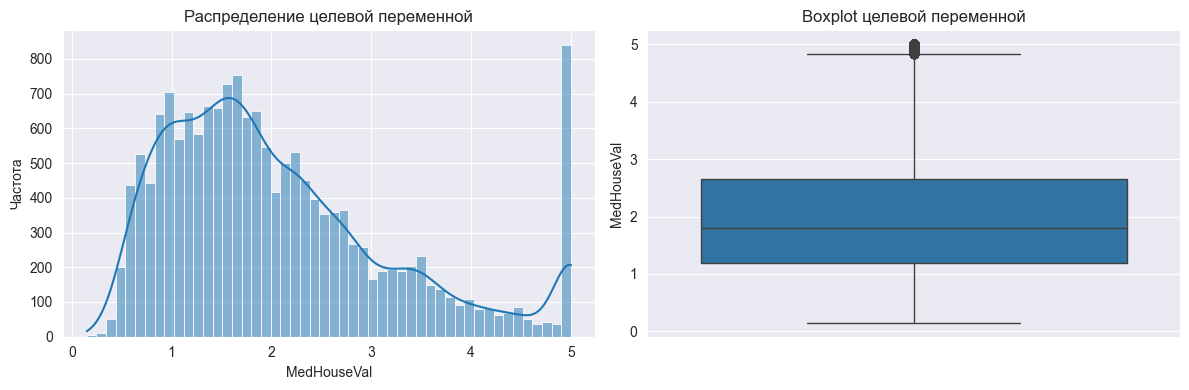

Минимум: 0.15
Максимум: 5.00
Медиана: 1.80
Среднее: 2.07
Q1: 1.20
Q3: 2.65
IQR: 1.45


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Распределение целевой переменной
plt.figure(figsize=(12, 4))

# Гистограмма
plt.subplot(1, 2, 1)
sns.histplot(y_train, bins=50, kde=True)
plt.xlabel('MedHouseVal')
plt.ylabel('Частота')
plt.title('Распределение целевой переменной')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=y_train)
plt.ylabel('MedHouseVal')
plt.title('Boxplot целевой переменной')

plt.tight_layout()
plt.show()
# Статистика
print(f"Минимум: {y_train.min():.2f}")
print(f"Максимум: {y_train.max():.2f}")
print(f"Медиана: {y_train.median():.2f}")
print(f"Среднее: {y_train.mean():.2f}")
print(f"Q1: {y_train.quantile(0.25):.2f}")
print(f"Q3: {y_train.quantile(0.75):.2f}")
print(f"IQR: {y_train.quantile(0.75) - y_train.quantile(0.25):.2f}")

## Корреляционная таблица

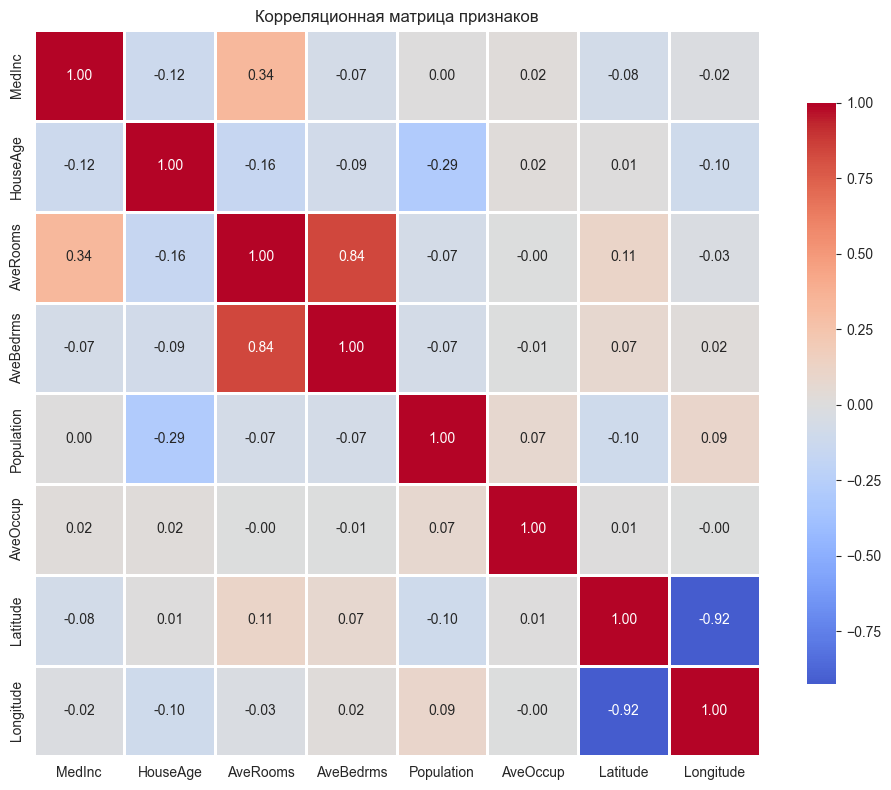

In [10]:
import numpy as np

# Корреляционная матрица
corr_matrix = X_train.corr()

# Тепловая карта
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})

plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

## Удаление коррелирующих признаков AveRooms и AveBedrms

In [11]:
# a. Выводы: высокая корреляция (0.84) между AveRooms и AveBedrms → удаляем один

# b. Удаляем AveBedrms
X_train_reduced = X_train.drop('AveBedrms', axis=1)
X_test_reduced = X_test.drop('AveBedrms', axis=1)

print(f"После удаления: {X_train_reduced.shape}")

# c. Повторяем п.3 (модель) и п.4 (метрики)
model_reduced = LinearRegression()
model_reduced.fit(X_train_reduced, y_train)

y_train_pred = model_reduced.predict(X_train_reduced)
y_test_pred = model_reduced.predict(X_test_reduced)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"\nTrain RMSE: {rmse_train:.4f}, R2: {r2_train:.4f}")
print(f"Test RMSE: {rmse_test:.4f}, R2: {r2_test:.4f}")

После удаления: (16512, 7)

Train RMSE: 0.7317, R2: 0.5995
Test RMSE: 0.7398, R2: 0.5823


Результат показывает:

RMSE увеличился на train (+0.0120), но уменьшился на test (-0.0058)

- Модель стала чуть хуже на обучающих данных

- Но лучше на тестовых (обобщает лучше)

R² уменьшился на train (-0.0131), но увеличился на test (+0.0065)

- Модель объясняет немного меньше вариации в обучающих данных

- Но объясняет больше вариации в новых данных

Выводы:

- Удаление коррелированного признака улучшило обобщающую способность

- Модель стала менее переобученной (разница между train/test уменьшилась)

- Trade-off: небольшая потеря точности на train ради лучшей работы на новых данных

- Это положительный результат — модель стала более устойчивой

## Исследование на выбросы

In [14]:
# Самый безопасный вариант - удаляем только экстремальные 1%
lower_bound = X_train_reduced.quantile(0.005)
upper_bound = X_train_reduced.quantile(0.995)

outliers = ((X_train_reduced < lower_bound) |
            (X_train_reduced > upper_bound)).any(axis=1)

print(f"Выбросов (0.5%-99.5%): {outliers.sum()} ({outliers.sum()/len(X_train_reduced)*100:.1f}%)")

# Удаление только экстремальных выбросов
X_train_no_out = X_train_reduced[~outliers]
y_train_no_out = y_train[~outliers]

print(f"После удаления: {X_train_no_out.shape}")

# Повтор п.3, п.4
model_clean = LinearRegression()
model_clean.fit(X_train_no_out, y_train_no_out)

y_train_pred = model_clean.predict(X_train_no_out)
y_test_pred = model_clean.predict(X_test_reduced)

rmse_train = np.sqrt(mean_squared_error(y_train_no_out, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train_no_out, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"\nTrain RMSE: {rmse_train:.4f}, R2: {r2_train:.4f}")
print(f"Test RMSE: {rmse_test:.4f}, R2: {r2_test:.4f}")

Выбросов (0.5%-99.5%): 934 (5.7%)
После удаления: (15578, 7)

Train RMSE: 0.6496, R2: 0.6753
Test RMSE: 0.9539, R2: 0.3057


Выводы:
- Любое удаление ухудшает тестовые метрики

- Train метрики улучшаются (модель переобучается)

- Выбросы в этом датасете — реальные данные (дорогие дома)